# Deep Learning PRO — Clase 1  
## Fundamentos, intuición matemática, conceptos clave y primer modelo

**Objetivo de la clase**  
Construir una base sólida de Deep Learning combinando teoría formal, intuición, ejemplos de uso y práctica en Keras.

---

## Ruta de aprendizaje

1. ¿Qué es realmente Deep Learning?  
2. Conceptos base: neurona, capa, pesos, sesgos, activación  
3. Cómo aprende una red: pérdida, gradiente, backpropagation  
4. Casos donde las redes neuronales sí funcionan muy bien  
5. Cuándo no conviene usarlas  
6. Primer modelo práctico con Keras  
7. Visualizaciones clave para entender el comportamiento del modelo

Autor: Josef Rodriguez


# 1. Definición real de Deep Learning

Una red neuronal profunda es una **aproximación paramétrica de funciones no lineales** construida mediante la composición de transformaciones lineales y activaciones no lineales.

$$
f(x) = W_L \, \sigma \Big( W_{L-1}\, \sigma(\cdots \sigma(W_1x+b_1)\cdots)+b_{L-1} \Big)+b_L
$$

## Interpretación

- $x$: vector de entrada  
- $W_i$: matriz de pesos de la capa $i$  
- $b_i$: sesgo de la capa $i$  
- $\sigma$: función de activación  
- $L$: número de capas  

## Idea central

Deep Learning no es “magia”.  
Es una combinación de:

- Álgebra lineal  
- Cálculo diferencial  
- Optimización numérica  
- Capacidad computacional  
- Datos suficientes  

## Definiciones clave

### Red neuronal artificial
Modelo compuesto por neuronas artificiales organizadas en capas, capaz de aprender patrones complejos a partir de datos.

### Capa
Conjunto de neuronas que transforman una representación de entrada en otra representación.

### Profundidad
Número de capas ocultas. A mayor profundidad, mayor capacidad de modelar relaciones complejas.

### Representación
Transformación interna de los datos que la red aprende automáticamente.


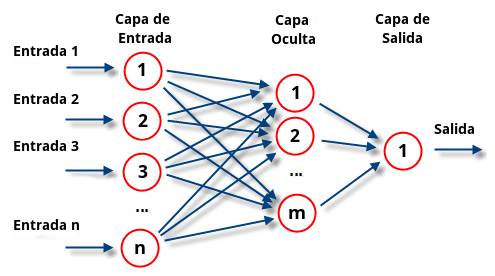

# 2. Neurona artificial: la unidad básica

Una neurona realiza dos pasos:

## Paso 1: combinación lineal

$$
z = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b
$$

## Paso 2: activación

$$
a = \sigma(z)
$$

## Significado de cada término

- **Inputs ($x_i$)**: variables de entrada  
- **Pesos ($w_i$)**: importancia relativa de cada variable  
- **Bias ($b$)**: desplazamiento o ajuste adicional  
- **Activación ($\sigma$)**: introduce no linealidad  

## Intuición sencilla

Una neurona se parece a una regresión lineal seguida de una transformación no lineal.

Si una red no tuviera funciones de activación, toda la red sería equivalente a una única transformación lineal, sin capacidad para modelar relaciones complejas.

# 3. Conceptos esenciales

## Peso
Parámetro que controla cuánto influye una entrada sobre la salida.

## Bias
Término adicional que permite desplazar la salida incluso cuando las entradas son cero.

## Activación
Función no lineal que permite aprender relaciones complejas.

## Forward pass
Proceso por el cual la información fluye desde la entrada hasta la predicción final.

## Loss function
Métrica que cuantifica el error del modelo.

## Backpropagation
Algoritmo que calcula cómo debe ajustarse cada parámetro para reducir la pérdida.

## Epoch
Una pasada completa por todo el conjunto de entrenamiento.

## Batch
Subconjunto de observaciones usado para actualizar pesos en cada paso.

## Learning rate
Tamaño del paso de actualización durante la optimización.

## Generalización
Capacidad de funcionar bien en datos no vistos.

# 4. Funciones de activación

Las funciones de activación permiten introducir no linealidad.  
Sin ellas, una red profunda sería equivalente a una transformación lineal.

## ReLU

$$
\text{ReLU}(x) = \max(0, x)
$$

**Ventajas:**

- Simple  
- Computacionalmente eficiente  
- Estable en la práctica  
- Mitiga parcialmente el problema de gradientes pequeños (vanishing gradient)  

## Sigmoid

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

**Ventajas:**

- Útil en problemas de clasificación binaria (salida probabilística)

**Problemas:**

- Se satura en valores extremos  
- Genera gradientes pequeños (vanishing gradients)  
- No está centrada en cero  

## Tanh

$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

**Ventajas:**

- Centrada en cero (mejora la dinámica del entrenamiento respecto a sigmoid)

**Problemas:**

- También se satura en valores extremos  
- Puede generar gradientes pequeños  

## Softmax

$$
P(y = i \mid x) = \frac{e^{z_i}}{\sum_j e^{z_j}}
$$

**Uso:**

- Clasificación multiclase  
- Convierte logits en probabilidades que suman 1  

## Intuición práctica

- **ReLU** → estándar en capas ocultas  
- **Sigmoid** → salida binaria  
- **Tanh** → alternativa a sigmoid (mejor centrado)  
- **Softmax** → salida multiclase  

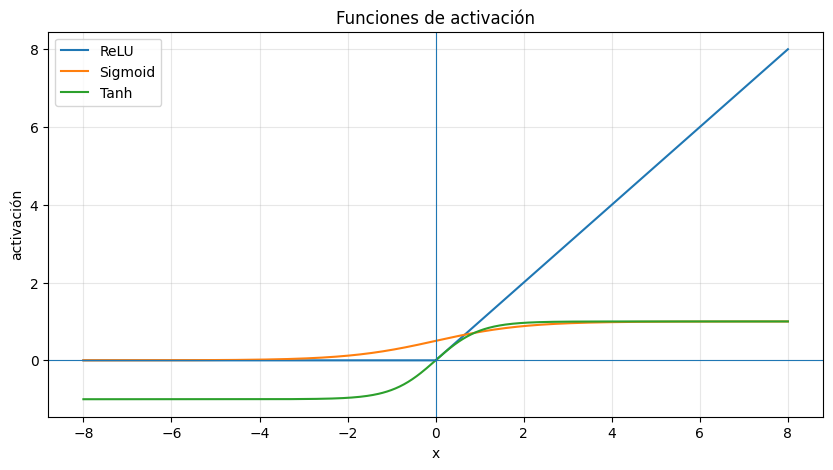

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-8, 8, 500)
relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

plt.figure(figsize=(10, 5))
plt.plot(x, relu, label="ReLU")
plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, tanh, label="Tanh")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("Funciones de activación")
plt.xlabel("x")
plt.ylabel("activación")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Cómo interpretar el gráfico

- **ReLU** anula los valores negativos y deja crecer los positivos.
- **Sigmoid** comprime toda la salida entre 0 y 1.
- **Tanh** comprime entre -1 y 1 y está centrada en cero.

En práctica moderna, ReLU y sus variantes suelen dominar en capas ocultas.

# 5. Funciones de pérdida

La red aprende minimizando una función de pérdida, que mide qué tan lejos están las predicciones del modelo respecto a los valores reales.

## Clasificación binaria: Binary Cross Entropy

$$
\mathcal{L}(y, \hat{y}) = -\left[y \log(\hat{y}) + (1 - y)\log(1 - \hat{y})\right]
$$

## Regresión: Mean Squared Error

$$
\mathcal{L}(y, \hat{y}) = \frac{1}{n} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

## Intuición

- Si el modelo está muy seguro y se equivoca, la penalización es alta  
- Si el modelo está cerca del valor correcto, la pérdida disminuye  
- La función de pérdida guía el proceso de optimización (ajuste de pesos)  

## Interpretación práctica

- **Binary Cross Entropy** → clasificación binaria (probabilidades)  
- **MSE** → regresión (errores continuos)  

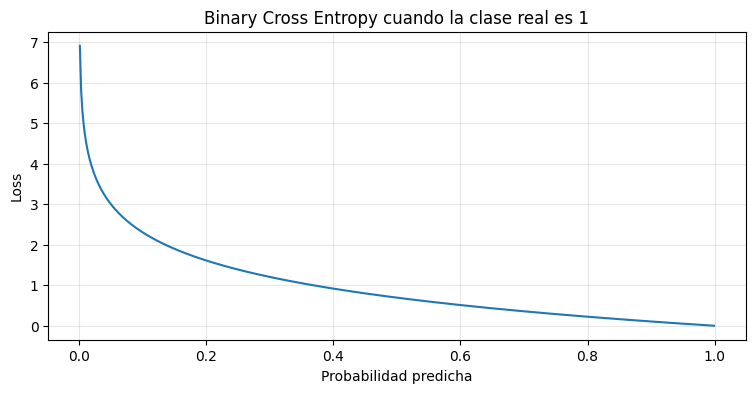

In [2]:
p = np.linspace(0.001, 0.999, 500)
y = 1
bce = -(y * np.log(p) + (1 - y) * np.log(1 - p))

plt.figure(figsize=(9, 4))
plt.plot(p, bce)
plt.title("Binary Cross Entropy cuando la clase real es 1")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

# 6. El problema de optimización

Entrenar una red neuronal consiste en encontrar los parámetros que minimizan la función de pérdida:

$$
\min_{\theta} \; \mathcal{L}(y, f(x;\theta))
$$

donde $\theta$ representa todos los pesos y sesgos del modelo.

## Gradient Descent

La regla de actualización básica es:

$$
\theta \leftarrow \theta - \eta \nabla_{\theta}\mathcal{L}
$$

donde:

- $\eta$: learning rate  
- $\nabla_{\theta}\mathcal{L}$: gradiente de la pérdida respecto a los parámetros  

## Idea intuitiva

El gradiente indica en qué dirección crece más la pérdida.  
Por eso actualizamos los parámetros en la dirección opuesta para minimizarla.

## Interpretación práctica

- Si el learning rate es muy alto → el modelo puede divergir  
- Si es muy bajo → el entrenamiento será muy lento  
- El objetivo es encontrar un equilibrio para converger de forma eficiente  

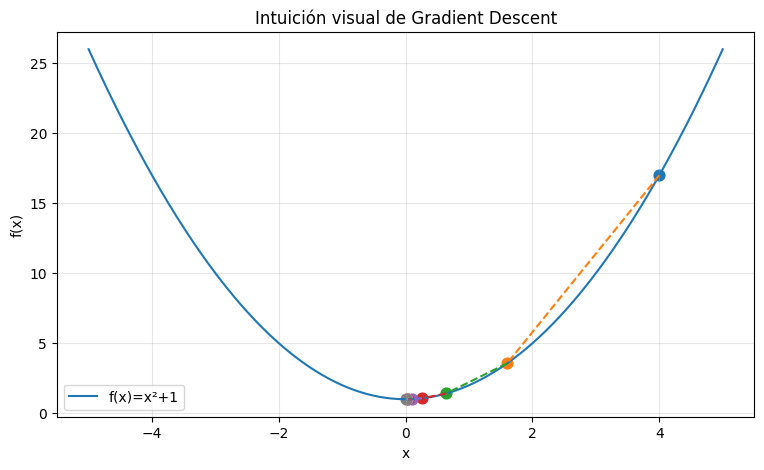

In [3]:
x = np.linspace(-5, 5, 400)
y = x**2 + 1

plt.figure(figsize=(9, 5))
plt.plot(x, y, label="f(x)=x²+1")

x0 = 4.0
eta = 0.3

for step in range(8):
    grad = 2 * x0
    x1 = x0 - eta * grad
    plt.scatter(x0, x0**2 + 1, s=60)
    plt.plot([x0, x1], [x0**2 + 1, x1**2 + 1], linestyle="--")
    x0 = x1

plt.title("Intuición visual de Gradient Descent")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 7. Backpropagation

## Definición
Backpropagation es el algoritmo que usa la regla de la cadena para calcular gradientes de la pérdida con respecto a cada parámetro.

## Idea general

1. **Forward pass**: la red genera una predicción.
2. Se calcula la pérdida.
3. **Backward pass**: el error se propaga hacia atrás.
4. Se actualizan pesos y sesgos.

## Por qué importa

Sin backpropagation, entrenar redes profundas con millones de parámetros sería inviable.

# 8. ¿Dónde funcionan bien las redes neuronales?

Aquí es donde debes aterrizar el criterio de negocio.

## 1. Visión computacional
Ejemplos:
- detección de objetos
- clasificación de imágenes
- diagnóstico asistido con imágenes médicas

¿Por qué funcionan bien?
- los datos tienen estructura espacial
- existen patrones jerárquicos: bordes → formas → objetos

## 2. Series temporales complejas
Ejemplos:
- demanda energética
- tráfico de red
- pronóstico de sensores industriales
- detección de anomalías en señales

¿Por qué funcionan bien?
- las dependencias suelen ser no lineales
- pueden capturar interacciones temporales complejas

## 3. Audio y señales
Ejemplos:
- reconocimiento de voz
- clasificación de sonidos
- mantenimiento predictivo con vibraciones

## 4. Recomendación avanzada
Ejemplos:
- interacción usuario-producto
- motores de recomendación

## 5. Detección de fraude y anomalías complejas
Ejemplos:
- comportamiento transaccional
- patrones de ataques
- eventos raros no lineales

## Regla importante
Que una red neuronal sea poderosa **no significa que sea la mejor opción para cualquier problema**.

# 9. ¿Cuándo no conviene usar Deep Learning?

## 1. Pocos datos
Las redes suelen necesitar volumen de datos y capacidad computacional.

## 2. Tabular clásico
En muchos problemas tabulares, LightGBM o XGBoost pueden rendir mejor y entrenar más rápido.

## 3. Alta necesidad de interpretabilidad inmediata
A veces un modelo lineal o un árbol es preferible.

## 4. Presupuesto computacional limitado
DL puede ser costoso en entrenamiento e inferencia.

## Mensaje pedagógico clave
No se trata de usar el modelo más “sofisticado”, sino el más adecuado al problema.

# 10. Ejemplo visual: frontera de decisión no lineal

Vamos a entrenar una red neuronal pequeña sobre un dataset sintético con forma no lineal.
La idea es mostrar qué aprende una red que un modelo lineal tendría dificultad para separar.

In [4]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

X, y = make_moons(n_samples=600, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

mlp = MLPClassifier(hidden_layer_sizes=(20, 20), activation="relu",
                    max_iter=2000, random_state=42)
mlp.fit(X_train, y_train)

pred = mlp.predict(X_test)
print("Accuracy test:", round(accuracy_score(y_test, pred), 4))

Accuracy test: 0.94


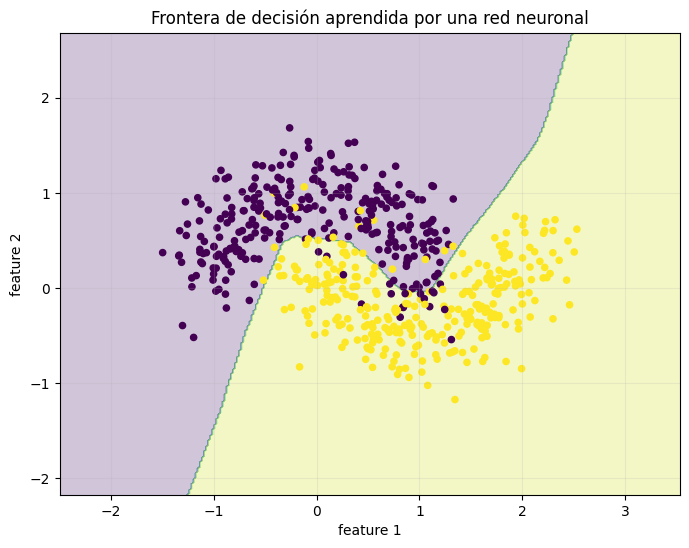

In [5]:
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
zz = mlp.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, zz, alpha=0.25)
plt.scatter(X[:, 0], X[:, 1], c=y, s=20)
plt.title("Frontera de decisión aprendida por una red neuronal")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.grid(alpha=0.2)
plt.show()

## Lectura del resultado

La red neuronal aprende una frontera de decisión curva y flexible.  
Eso muestra una de sus ventajas más importantes: modelar relaciones no lineales complejas.

# 11. Primer modelo en Keras

Ahora construimos un modelo con TensorFlow/Keras sobre un problema de clasificación binaria sintético.

## Qué queremos enseñar aquí

- estructura de un modelo `Sequential`
- capas densas
- activación de salida sigmoide
- compilación con optimizer, loss y métricas
- entrenamiento con `fit`
- lectura básica del historial de entrenamiento

In [10]:
# Si no tienes TensorFlow instalado, puedes comentar esta celda o instalarlo en tu entorno.
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=2500,
    n_features=12,
    n_informative=8,
    n_redundant=2,
    class_sep=1.2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu", input_shape=(X_train_sc.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history = model.fit(
    X_train_sc, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=0
)

model.evaluate(X_test_sc, y_test, verbose=0)

/Users/josefrodriguez/repos/ML_course/ML-course/ml_course_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[0.20648102462291718, 0.9279999732971191, 0.974492073059082]

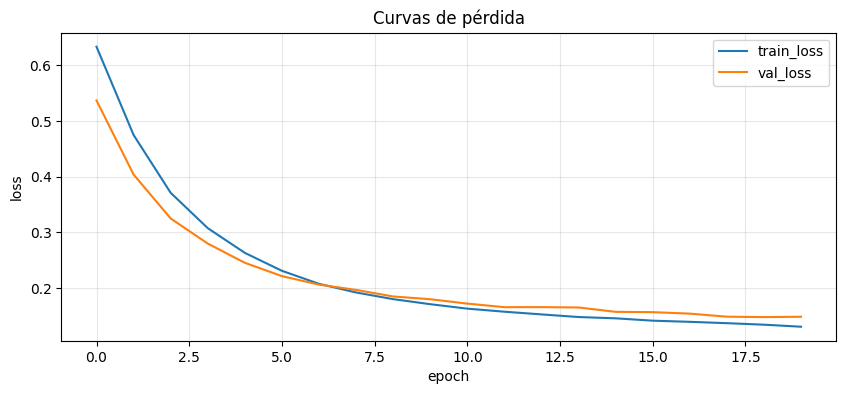

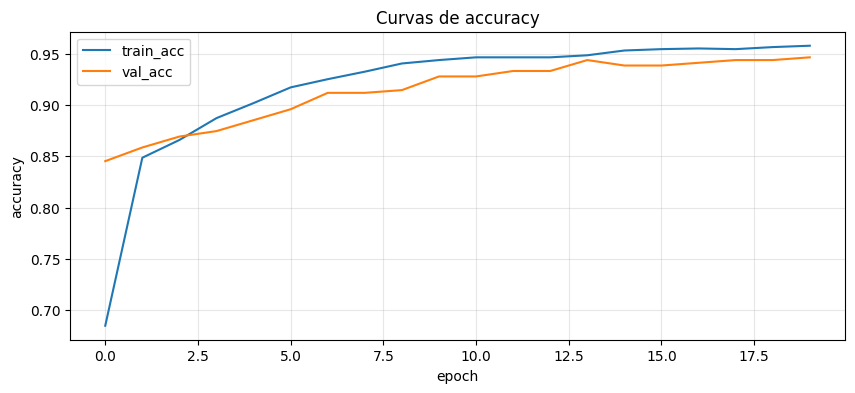

In [8]:
history_dict = history.history

plt.figure(figsize=(10, 4))
plt.plot(history_dict["loss"], label="train_loss")
plt.plot(history_dict["val_loss"], label="val_loss")
plt.title("Curvas de pérdida")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_dict["accuracy"], label="train_acc")
plt.plot(history_dict["val_accuracy"], label="val_acc")
plt.title("Curvas de accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 12. Conceptos prácticos del modelo

## ¿Por qué escalamos los datos?
Las redes suelen entrenar de forma más estable cuando las variables tienen escalas comparables.

## ¿Por qué usar `binary_crossentropy`?
Porque el target es binario y la salida es una probabilidad.

## ¿Por qué `sigmoid` en la salida?
Porque queremos valores en el rango \([0,1]\).

## ¿Qué significa una epoch?
Una pasada completa por los datos de entrenamiento.

## ¿Qué significa batch size?
Cuántos ejemplos usa el optimizador antes de actualizar parámetros.

# 13. Overfitting y generalización

## Underfitting
El modelo es demasiado simple y no aprende suficiente estructura.

## Overfitting
El modelo memoriza los datos de entrenamiento y falla en datos nuevos.

## Generalización
El objetivo real es rendir bien fuera de la muestra.

### Señales de overfitting
- train loss baja mucho
- validation loss deja de bajar o empieza a subir

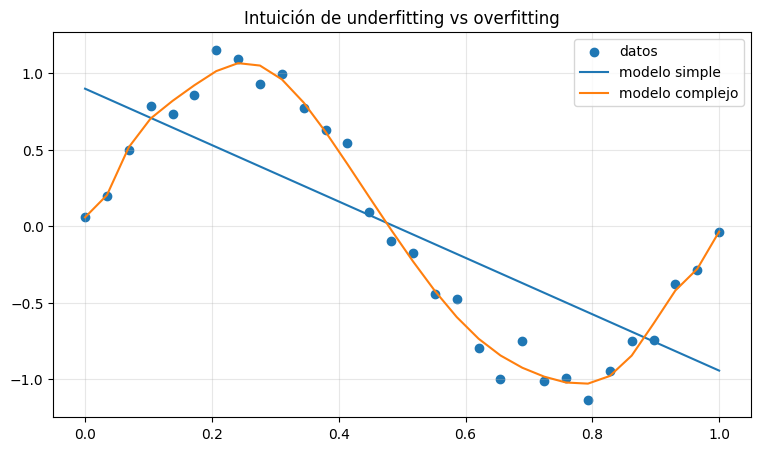

In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

rng = np.random.RandomState(42)
X_demo = np.linspace(0, 1, 30).reshape(-1, 1)
y_demo = np.sin(2 * np.pi * X_demo).ravel() + rng.normal(0, 0.12, size=30)

# modelo simple
lr_simple = LinearRegression().fit(X_demo, y_demo)
y_simple = lr_simple.predict(X_demo)

# modelo muy complejo
poly = PolynomialFeatures(degree=12)
X_poly = poly.fit_transform(X_demo)
lr_complex = LinearRegression().fit(X_poly, y_demo)
y_complex = lr_complex.predict(X_poly)

plt.figure(figsize=(9, 5))
plt.scatter(X_demo, y_demo, label="datos")
plt.plot(X_demo, y_simple, label="modelo simple")
plt.plot(X_demo, y_complex, label="modelo complejo")
plt.title("Intuición de underfitting vs overfitting")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 14. Resumen ejecutivo de la clase

## Lo que debe quedar claro

- Una red neuronal aprende funciones no lineales.
- La neurona artificial combina entradas, pesos, sesgo y activación.
- El aprendizaje se guía por una función de pérdida.
- El gradiente y backpropagation son el corazón del entrenamiento.
- Las redes funcionan muy bien cuando existen patrones complejos.
- No siempre son la mejor opción en tabular clásico.
- Keras permite construir rápidamente modelos prácticos.

# 15. Ejercicios propuestos

1. Cambia la activación de ReLU a Tanh y compara curvas de entrenamiento.  
2. Agrega una capa oculta adicional y revisa si mejora o empeora el rendimiento.  
3. Modifica el batch size a 16, 64 y 128. ¿Qué cambia?  
4. Cambia el learning rate del optimizador Adam.  
5. Compara este modelo con un Logistic Regression del mismo dataset.

---

# 16. Preguntas de entrevista para repasar

1. ¿Por qué una red sin activaciones sigue siendo lineal?  
2. ¿Qué diferencia hay entre epoch y batch?  
3. ¿Por qué usamos sigmoid en clasificación binaria?  
4. ¿Qué significa minimizar una loss function?  
5. ¿Cuándo preferirías un modelo no profundo?

# 16. Puente hacia la siguiente clase y hacia producción

Hasta aquí ya tienes la base conceptual para construir y entrenar una red neuronal densa.  
Sin embargo, un perfil fuerte en Machine Learning no se queda en “entrenar un modelo que corre”.

En la siguiente etapa debemos responder tres preguntas mucho más profesionales:

    ## 1. ¿Cómo se compara Deep Learning contra LightGBM en datos tabulares?
No basta con asumir que una red neuronal gana.  
En muchos problemas tabulares, especialmente con datasets medianos y variables estructuradas, LightGBM puede ofrecer:

- mejor AUC
- menor tiempo de entrenamiento
- menor costo computacional
- tuning más simple

    ## 2. ¿Cómo se aterriza esto en un proyecto aplicado real?
Necesitamos pasar de ejemplos sintéticos a un flujo que se parezca a fraude, churn, riesgo o DDoS.

    ## 3. ¿Cómo se construye un pipeline completo?
Un modelo útil debe pensarse con mentalidad de ciclo de vida:

$$
\text{Train} \rightarrow \text{Validate} \rightarrow \text{Test} \rightarrow \text{Deploy} \rightarrow \text{Monitor}
$$

Ese enfoque es el que realmente diferencia a un practicante de un ingeniero o científico de datos con criterio de producción.